In [10]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [7]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

## 1. NumPy Operations

In [2]:
# TODO: Create a NumPy array and perform vectorized operations

arr = np.array([1, 2, 3, 4, 5])
result = arr * 2

## 2. Compare Loop vs Vectorization

In [3]:
# TODO: Compare speed using %timeit
%timeit arr * 2
%timeit [x * 2 for x in arr]

571 ns ± 15.1 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
723 ns ± 6.75 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


## 3. Load and Inspect Dataset

In [10]:
from src.config import get_data_dir
data_dir = get_data_dir()
print(data_dir)

/Users/xiaoqihuang/bootcamp_xiaoqi_huang/project/data


In [11]:
# TODO: Load CSV and inspect with .head(), .info(), .describe()
df = pd.read_csv(data_dir / "raw" / "dummy.csv")
df.head(), df.info(), df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   category  10 non-null     str  
 1   value     10 non-null     int64
 2   date      10 non-null     str  
dtypes: int64(1), str(2)
memory usage: 372.0 bytes


(  category  value        date
 0        A     10  2025-08-01
 1        B     15  2025-08-02
 2        A     12  2025-08-03
 3        B     18  2025-08-04
 4        C     25  2025-08-05,
 None,
            value
 count  10.000000
 mean   17.600000
 std     7.381659
 min    10.000000
 25%    12.250000
 50%    14.500000
 75%    23.250000
 max    30.000000)

## 4. Summary Statistics and Groupby

In [12]:
# TODO: Perform groupby and save output to data/processed/
summary = df.groupby('category').mean(numeric_only=True).reset_index()
summary.to_csv(data_dir / "processed" / "summary.csv", index=False)
summary

,category,value
0,A,11.500000
1,B,15.666667
2,C,27.666667


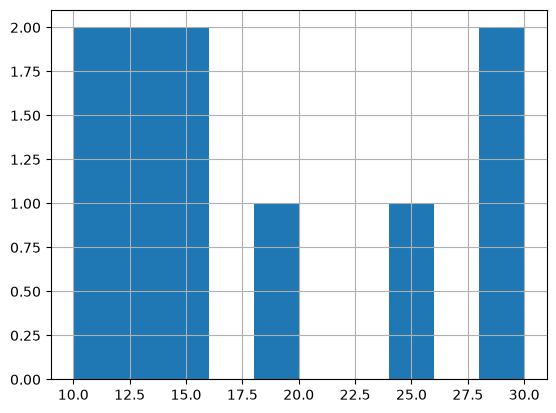

In [13]:
df['value'].hist()
plt.savefig(data_dir / "processed" / "histogram.png")